In [1]:
import pandas as pd
d=pd.read_csv("mushrooms.csv")
d

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [3]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
cols = ['class','cap-shape','cap-surface','cap-color','odor']

for col in cols:
    d[col] = l.fit_transform(d[col])

print(d[cols])


      class  cap-shape  cap-surface  cap-color  odor
0         1          5            2          4     6
1         0          5            2          9     0
2         0          0            2          8     3
3         1          5            3          8     6
4         0          5            2          3     5
...     ...        ...          ...        ...   ...
8119      0          3            2          4     5
8120      0          5            2          4     5
8121      0          2            2          4     5
8122      1          3            3          4     8
8123      0          5            2          4     5

[8124 rows x 5 columns]


In [4]:
x=d[['cap-shape','cap-surface','cap-color','odor']]
y=d['class']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
s1=DecisionTreeClassifier(criterion="gini",max_depth=3)
s1.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred=s1.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 1], shape=(2031,))

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
accuracy_score(y_test,y_pred)

0.9817823732151649

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

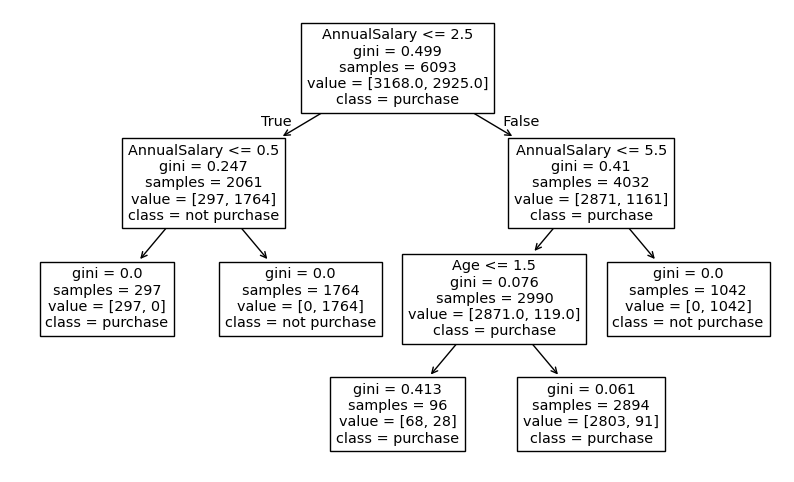

In [13]:
plt.figure(figsize=(10,6))
plot_tree(s1,feature_names=["User ID","Gender","Age","AnnualSalary"],class_names=["purchase","not purchase"])
plt.show()